# Notebook 01 — Generate Synthetic Data

This notebook generates the synthetic paired-triglyceride dataset used in the benchmark.

**Critical generation order:**
1. Generate TCR (primary latent response) first
2. Derive TG4h = TG0h × (1 − TCR/100) after TCR is set
3. NEVER reverse this order — reversing causes definitional leakage

**Scenarios:**
- `null` — TCR independent of all predictors (expected clean AUROC ≈ 0.48–0.52)
- `weak_signal` — age, HDL, BMI have small effects (AUROC ≈ 0.55–0.60)
- `moderate_signal` — TG0h and BMI moderate effects (AUROC ≈ 0.65–0.75)
- `wbv_positive` — WBV strong positive control (AUROC ≈ 0.80+)


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import yaml
import json
import matplotlib.pyplot as plt
from pathlib import Path

from src.generate_synthetic_data import generate, build_metadata

## 1. Generate null-scenario dataset (main analysis, seed 2026)

In [2]:
config_path = Path('../config/generator_null.yaml')
with open(config_path) as f:
    cfg_null = yaml.safe_load(f)

SEED = 2026
N    = 1500

df_null = generate(cfg_null, seed=SEED, n=N)
print(f"Shape: {df_null.shape}")
df_null.head()

Generating [null] seed=2026 n=1500:   0%|                          | 0/13 [00:00<?, ?it/s]

[null] age:   0%|                                                  | 0/13 [00:00<?, ?it/s]

[null] sex:   8%|███▏                                     | 1/13 [00:00<00:00, 471.43it/s]

[null] bmi:  15%|██████▎                                  | 2/13 [00:00<00:00, 724.53it/s]

[null] hct:  23%|█████████▍                               | 3/13 [00:00<00:00, 726.96it/s]

...

[null] plausibility check:  85%|█████████████████████▏   | 11/13 [00:00<00:00, 940.81it/s]

[null] assembling DataFrame:  92%|█████████████████████▏ | 12/13 [00:00<00:00, 992.87it/s]

[null] assembling DataFrame: 100%|███████████████████████| 13/13 [00:00<00:00, 903.87it/s]

Shape: (1500, 12)


,record_id,age,sex,bmi,hct,tp,hdl,ldl,wbv,tg0h,tcr,tg4h
0,SYN00001,43.7,0,20.2,46.3,6.79,53.5,134.9,6.358,624.6,62.14,236.4
1,SYN00002,56.3,1,23.9,40.3,7.17,51.5,150.2,5.705,571.6,49.41,289.2
2,SYN00003,52.0,0,22.3,39.7,7.04,45.8,175.3,5.612,574.9,62.88,213.4
3,SYN00004,49.6,1,22.1,44.8,7.47,42.6,145.8,6.292,720.2,91.78,59.2
4,SYN00005,49.2,1,24.6,44.2,7.08,51.7,157.6,6.153,845.4,52.30,403.3


In [3]:
# Save
out_path = Path('../data/paired_tcr_null_v1_seed2026.csv')
out_path.parent.mkdir(parents=True, exist_ok=True)
df_null.to_csv(out_path, index=False)

meta = build_metadata(cfg_null, SEED, N, df_null, out_path)
with open(out_path.with_suffix('.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print(f"Saved: {out_path}")

Saved: ..\data\paired_tcr_null_v1_seed2026.csv


## 2. Descriptive statistics

In [4]:
numeric_cols = ['age', 'bmi', 'hct', 'tp', 'wbv', 'hdl', 'ldl', 'tg0h', 'tcr', 'tg4h']
df_null[numeric_cols].describe().round(2)

,age,bmi,hct,tp,wbv,hdl,ldl,tg0h,tcr,tg4h
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00
mean,53.15,24.10,41.95,6.87,5.85,50.83,132.75,617.39,51.30,301.31
std,9.46,2.86,3.77,0.61,0.46,9.59,26.58,129.86,17.26,126.30
min,23.60,16.30,31.50,5.03,4.45,25.20,70.20,398.70,-6.17,6.20
25%,46.88,22.20,39.40,6.43,5.53,44.28,113.60,525.95,39.21,215.58
50%,53.50,24.10,41.90,6.86,5.85,50.60,131.80,589.25,51.67,288.30
75%,59.90,26.00,44.60,7.28,6.17,57.20,150.93,678.32,62.70,379.28
max,74.90,32.90,53.80,8.64,7.23,83.60,214.40,1624.60,98.77,948.90


In [5]:
# Verify label construction (illustrative — do NOT use this in modelling)
global_q1 = df_null['tcr'].quantile(0.25)
prevalence = (df_null['tcr'] <= global_q1).mean()
print(f"Q1 TCR (illustrative): {global_q1:.2f}")
print(f"Prevalence at Q1 (for reference only): {prevalence:.3f}")
print("NOTE: The label must be computed inside each training fold, not from global Q1.")

Q1 TCR (illustrative): 39.21
Prevalence at Q1 (for reference only): 0.250
NOTE: The label must be computed inside each training fold, not from global Q1.


## 3. Verify WBV formula

In [6]:
wbv_check = 0.12 * df_null['hct'] + 0.17 * (df_null['tp'] - 2.07)
max_diff = (wbv_check - df_null['wbv']).abs().max()
print(f"Max WBV formula deviation: {max_diff:.6f}  (expect < 0.01)")
assert max_diff < 0.01, "WBV formula check failed! (tolerance 0.01 for np.round(wbv,3) artefact)"

Max WBV formula deviation: 0.006800  (expect < 0.01)


## 4. Verify TG4h derivation

In [7]:
tg4h_check = df_null['tg0h'] * (1 - df_null['tcr'] / 100.0)
# Some rows may be clipped — check unclipped fraction
clipped = (df_null['tg4h'] != tg4h_check.round(1)).sum()
print(f"Rows where TG4h was clipped to valid range: {clipped}/{N}")

Rows where TG4h was clipped to valid range: 303/1500


## 5. Distribution plots

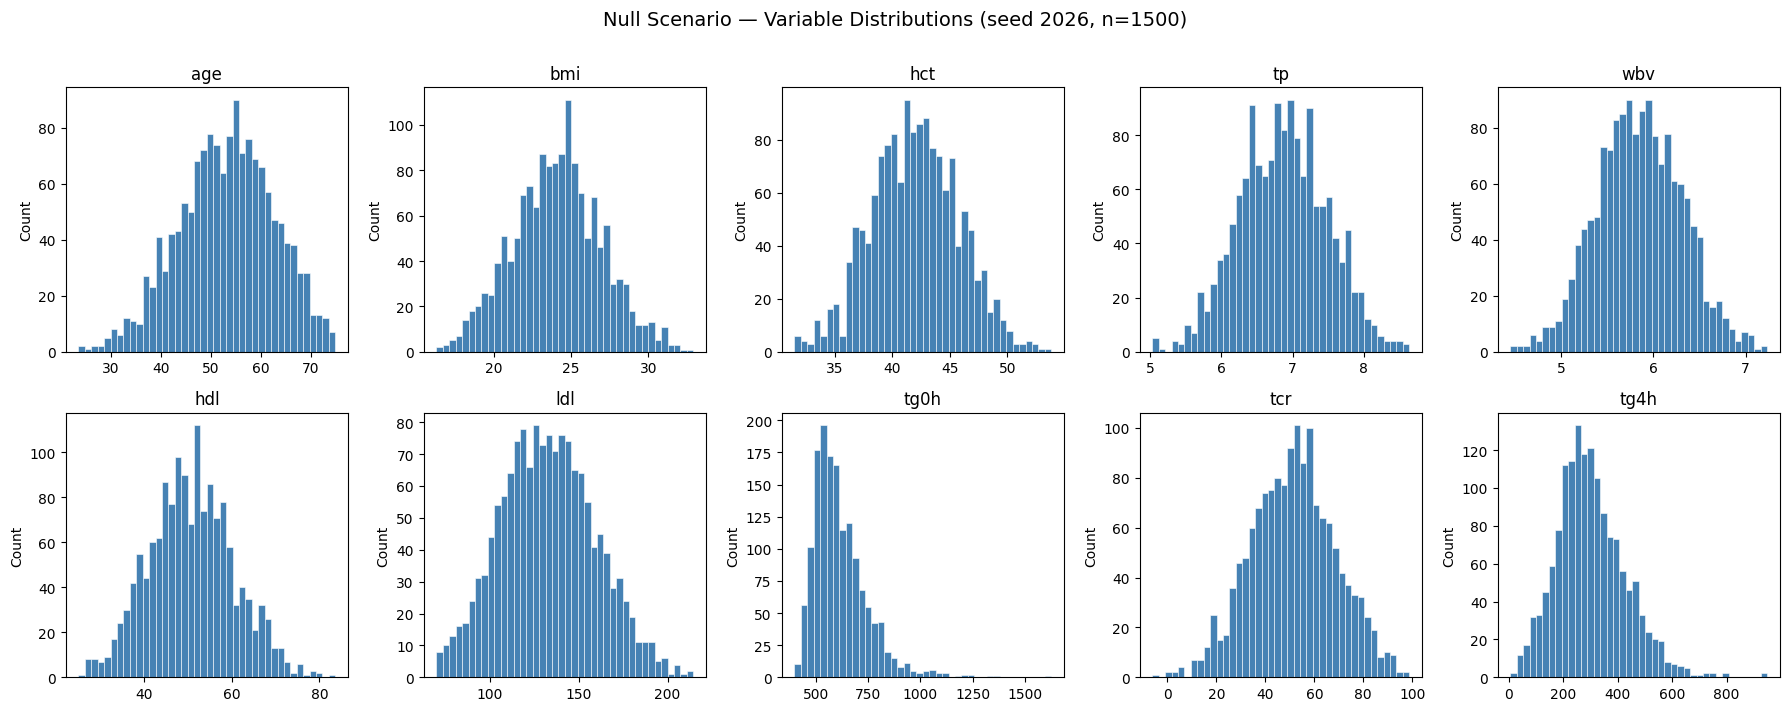

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df_null[col], bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('Count')
plt.suptitle('Null Scenario — Variable Distributions (seed 2026, n=1500)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/01_distributions_null.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Generate all scenario datasets

In [9]:
scenarios = [
    ('generator_weak_signal.yaml',     'paired_tcr_weak_signal_v1_seed2026.csv'),
    ('generator_moderate_signal.yaml', 'paired_tcr_moderate_signal_v1_seed2026.csv'),
    ('generator_wbv_positive.yaml',    'paired_tcr_wbv_positive_v1_seed2026.csv'),
]

for config_file, out_file in scenarios:
    with open(f'../config/{config_file}') as f:
        cfg = yaml.safe_load(f)
    df = generate(cfg, seed=2026, n=1500)
    out = Path(f'../data/{out_file}')
    df.to_csv(out, index=False)
    print(f"{out_file}: TCR mean={df['tcr'].mean():.2f}, sd={df['tcr'].std():.2f}")

Generating [weak_signal] seed=2026 n=1500:   0%|                   | 0/13 [00:00<?, ?it/s]

[weak_signal] age:   0%|                                           | 0/13 [00:00<?, ?it/s]

[weak_signal] sex:   8%|██▌                               | 1/13 [00:00<00:00, 661.88it/s]

[weak_signal] bmi:  15%|█████                            | 2/13 [00:00<00:00, 1047.01it/s]

[weak_signal] hct:  23%|███████▊                          | 3/13 [00:00<00:00, 948.51it/s]

...

[wbv_positive] tg4h = tg0h × (1 − tcr/100):  77%|█████▍ | 10/13 [00:00<00:00, 1084.14it/s]

[wbv_positive] plausibility check:  85%|█████████████▌  | 11/13 [00:00<00:00, 1130.04it/s]

[wbv_positive] assembling DataFrame:  92%|████████████▉ | 12/13 [00:00<00:00, 1172.66it/s]

[wbv_positive] assembling DataFrame: 100%|██████████████| 13/13 [00:00<00:00, 1083.52it/s]

paired_tcr_wbv_positive_v1_seed2026.csv: TCR mean=52.32, sd=10.28
